In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import cv2

def reward(input,output):
    return indentity_preservation_score(input,output) + background_preservation_score(input, output) + attractivness_diff(input,output)

# Load the image
image = "../drive/MyDrive/Data_Collection/SCUT-FBP-1.jpg"

# Define the DQN model architecture
model = Sequential()
model.add(Dense(64, input_dim=18*512, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(4, activation='linear'))
model.compile(loss='mse', optimizer=Adam(lr=0.001))

# Define the replay memory
class ReplayMemory:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []

    def push(self, state, action, reward, next_state):
        if len(self.memory) >= self.capacity:
            self.memory.pop(0)
        self.memory.append((state, action, reward, next_state))

    def sample(self, batch_size):
        batch = np.random.choice(self.memory, batch_size, replace=False)
        states, actions, rewards, next_states = zip(*batch)
        return states, actions, rewards, next_states

replay_memory = ReplayMemory(capacity=1000)

# Exploration-exploitation strategy
def epsilon_greedy_policy(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randn(4)
    q_values = model.predict(state)
    return q_values[0]

# Training loop
def train(model, replay_memory, epsilon, gamma, batch_size):
    states, actions, rewards, next_states = replay_memory.sample(batch_size)
    targets = model.predict(np.array(states))
    next_q_values = model.predict(np.array(next_states))
    for i in range(batch_size):
        targets[i][actions[i]] = rewards[i] + gamma * np.max(next_q_values[i])
    model.fit(np.array(states), np.array(targets), epochs=1, verbose=0)

# Define the parameters
epsilon = 1.0  # initial exploration rate
epsilon_min = 0.01
epsilon_decay = 0.995
gamma = 0.99  # discount factor
batch_size = 32
num_episodes = 1000

desired_reward_threshold = 4

for episode in range(num_episodes):
    encoding = encode(image)  # Get the initial encoding
    input = decode(encoding)
    while True:
        action = epsilon_greedy_policy(encoding, epsilon)
        action[1],action[2] = abs(action[1]),abs(action[2])
        if action[1] > action[2]:
          action[1] = action[2]
        action = action.astype(int).tolist()
        edited_encoding = edit(encoding, action)
        decoded_image = decode(edited_encoding)
        episode_reward = reward(input,decoded_image)
        replay_memory.push(encoding, action, episode_reward, edited_encoding)
        encoding = edited_encoding
        print(len(replay_memory.memory))
        if len(replay_memory.memory) >= batch_size:
            print(len(replay_memory.memory))
            train(model, replay_memory, epsilon, gamma, batch_size)
        if episode_reward >= desired_reward_threshold:  # Define your desired reward threshold
            break
        epsilon *= epsilon_decay
        epsilon = max(epsilon, epsilon_min)

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import cv2

def image_reward(input,output):
    return indentity_preservation_score(input,output) + background_preservation_score(input, output) + attractivness_diff(input,output)

def action_reward(action):
    if action[1] < 0 or action[2] < 0:
       return -5
    if action[1] > action[2]:
       return -5
    return None

# Load the image
image = "../drive/MyDrive/Data_Collection/SCUT-FBP-1.jpg"

# Define the DQN model architecture
model = Sequential()
model.add(Dense(64, input_dim=18*512, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(4, activation='linear'))
model.compile(loss='mse', optimizer=Adam(lr=0.001))

# Define the replay memory
class ReplayMemory:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []

    def push(self, state, action, reward, next_state):
        if len(self.memory) >= self.capacity:
            self.memory.pop(0)
        self.memory.append((state, action, reward, next_state))

    def sample(self, batch_size):
        batch = np.random.choice(self.memory, batch_size, replace=False)
        states, actions, rewards, next_states = zip(*batch)
        return states, actions, rewards, next_states

replay_memory = ReplayMemory(capacity=1000)

import tensorflow as tf
def epsilon_greedy_policy(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randn(4)
    print("PREDICT")
    q_values = model.predict(state)
    return q_values[0]

# Training loop
def train(model, replay_memory, epsilon, gamma, batch_size):
    states, actions, rewards, next_states = replay_memory.sample(batch_size)
    targets = model.predict(np.array(states))
    next_q_values = model.predict(np.array(next_states))
    for i in range(batch_size):
        targets[i][actions[i]] = rewards[i] + gamma * np.max(next_q_values[i])
    model.fit(np.array(states), np.array(targets), epochs=1, verbose=0)

# Define the parameters
epsilon = 1.0  # initial exploration rate
epsilon_min = 0.01
epsilon_decay = 0.995
gamma = 0.99  # discount factor
batch_size = 32
num_episodes = 1000

desired_reward_threshold = 1

for episode in range(num_episodes):
    encoding = encode(image)
    input_image = decode(encoding)
    while True:
        action = epsilon_greedy_policy(encoding, epsilon)
        episode_reward = action_reward(action)
        if episode_reward == None:
          action = action.astype(int).tolist()
          edited_encoding = edit(encoding, action)
          decoded_image = decode(edited_encoding)
          episode_reward = image_reward(input_image,decoded_image)
        replay_memory.push(encoding, action, episode_reward, edited_encoding)
        encoding = edited_encoding
        print(len(replay_memory.memory))
        if len(replay_memory.memory) >= batch_size:
            print(len(replay_memory.memory))
            train(model, replay_memory, epsilon, gamma, batch_size)
        if episode_reward >= desired_reward_threshold:  # Define your desired reward threshold
            break
        epsilon *= epsilon_decay
        epsilon = max(epsilon, epsilon_min)

In [ ]:
import os
import pandas as pd
from PIL import Image
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models


In [ ]:
image_dir = "drive/MyDrive/Data_Collection"
label_file = "drive/MyDrive/Rating_Collection/Attractiveness label.xlsx"

In [ ]:
label_df = pd.read_excel(label_file)

In [ ]:
def preprocess_images(image_dir, label_df):
    image_data = []
    labels = []

    for _, row in label_df.iterrows():
        image_path = os.path.join(image_dir, f"SCUT-FBP-{int(row['#Image'])}.jpg")
        image = Image.open(image_path)
        image = image.resize((224, 224))
        image_array = np.array(image) / 255.0
        image_data.append(image_array)
        labels.append(row['Attractiveness label'])

    image_data = np.array(image_data)
    labels = np.array(labels)

    return image_data, labels

In [ ]:
image_data, labels = preprocess_images(image_dir, label_df)

In [ ]:
train_ratio = 0.9999999
train_samples = int(len(image_data) * train_ratio)

train_images = image_data[:train_samples]
train_labels = labels[:train_samples]

val_images = image_data[train_samples:]
val_labels = labels[train_samples:]

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])


In [ ]:
model.fit(train_images, train_labels, epochs=10, validation_data=(val_images, val_labels))

Epoch 1/10
16/16 [==============================] - 15s 118ms/step - loss: 57.2478 - mae: 4.2973 - val_loss: 8.4903 - val_mae: 2.9138
Epoch 2/10
16/16 [==============================] - 1s 55ms/step - loss: 1.8474 - mae: 1.0890 - val_loss: 1.7645 - val_mae: 1.3283
Epoch 3/10
16/16 [==============================] - 1s 48ms/step - loss: 0.6196 - mae: 0.6259 - val_loss: 0.2981 - val_mae: 0.5460
Epoch 4/10
16/16 [==============================] - 1s 48ms/step - loss: 0.4859 - mae: 0.5388 - val_loss: 0.1903 - val_mae: 0.4363
Epoch 5/10
16/16 [==============================] - 1s 46ms/step - loss: 0.4356 - mae: 0.5079 - val_loss: 0.1552 - val_mae: 0.3940
Epoch 6/10
16/16 [==============================] - 1s 47ms/step - loss: 0.4040 - mae: 0.4925 - val_loss: 0.4858 - val_mae: 0.6970
Epoch 7/10
16/16 [==============================] - 1s 47ms/step - loss: 0.3815 - mae: 0.4724 - val_loss: 0.0307 - val_mae: 0.1753
Epoch 8/10
16/16 [==============================] - 1s 48ms/step - loss: 0.3712 

In [ ]:
import matplotlib.pyplot as plt

def predict_and_plot(images, model):
    for image_path in images:
        # Load and preprocess the image
        image = Image.open(image_path)
        image = image.resize((224, 224))  # Adjust the size as needed
        image_array = np.array(image) / 255.0  # Normalize pixel values
        image_input = np.expand_dims(image_array, axis=0)

        # Perform prediction
        score = model_test.predict(image_input)[0][0]

        # Plot the image without axis
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"Predicted Score: {score:.3f}")
        plt.show()


1/1 [==============================] - 0s 120ms/step


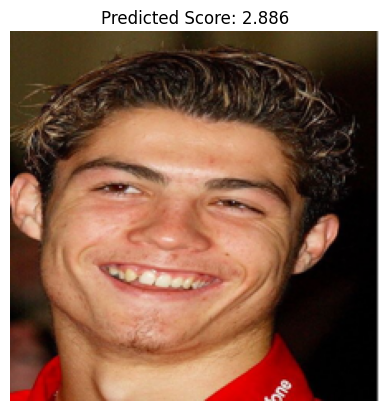

1/1 [==============================] - 0s 31ms/step


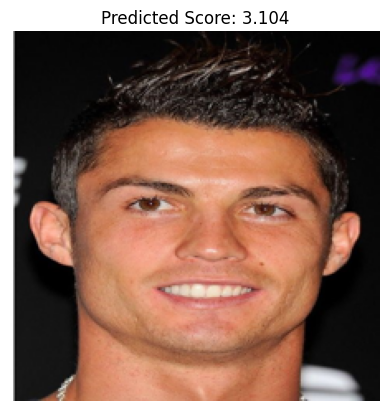

In [ ]:
image_files = ['ronaldo_after.jpg','ronaldo_before.jpg']

predict_and_plot(image_files, model)


In [ ]:
model.save('drive/MyDrive/Attractivness_eval_model.h5')